# Image Cleaning

## Imports

In [1]:
from pathlib import Path
import pypff
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# avoids crowded subplots
def colorbar(mappable, label=None):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    if label is not None:
        cbar.set_label(label)
    plt.sca(last_axes)
    return cbar

# source: https://joseph-long.com/writing/colorbars/

## Read Test Data

In [3]:
data_file = Path("../test_data/20260709/obs_Palomar.start_2026-07-09T08:35:09Z.runtype_obs-test.pffd/").resolve()
data_path = Path(data_file).resolve()
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")
# else:
#     print(data_path)

In [4]:
# read ph1024 data file (Fern, preflip run)
file = str(data_path / "start_2026-07-09T08:35:53Z.dp_ph1024.bpp_2.module_253.seqno_0.pff")
pff = pypff.io.datapff(file)
data, metadata = pff.readpff(metadata=True)

## Threshold Cleaning

Let's start by plotting a "random" image (20260709, MGRO J2019+37, Winter, event)

In [5]:
event_num = 3000

In [6]:
event = data[event_num]

Text(0.5, 1.0, 'Raw Image')

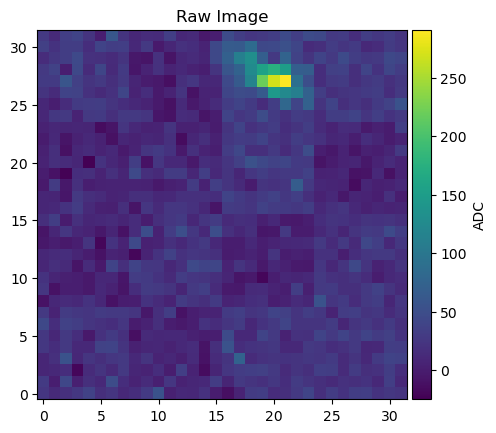

In [7]:
fig = plt.figure()
image = plt.imshow(event.reshape(32,32), aspect="equal", origin='lower')
colorbar(image, "ADC")
plt.title("Raw Image")

Now we need to import the cleaning functions

First we need to do a pedestal subtraction and generate the pedestal variance

In [8]:
from heap.make_pedestals import calculate_pedestal_and_pedvar

We probably shouldn't use the whole night to make the pedestal. Lets naively use some subset of events centered around this particular event number

In [9]:
start = event_num - 100
end = event_num + 100
pedestal, pedestal_variance = calculate_pedestal_and_pedvar(data[start:end])

Text(0.5, 1.0, 'Pedestal')

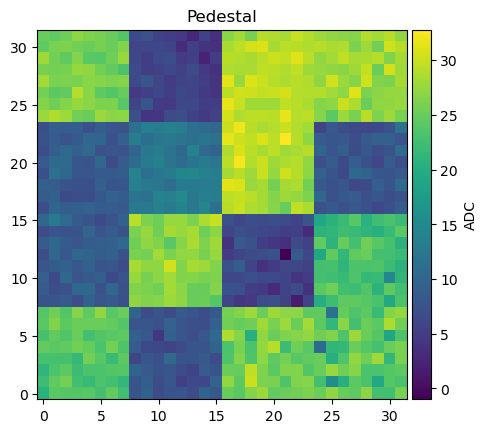

In [10]:
fig = plt.figure()
image=plt.imshow(pedestal.reshape(32,32), aspect="equal", origin='lower')
colorbar(image, "ADC")
plt.title("Pedestal")

In [11]:
# pedestal subtraction
ped_subtracted_event = event - pedestal

Text(0.5, 1.0, 'Pedestal Subtracted Image')

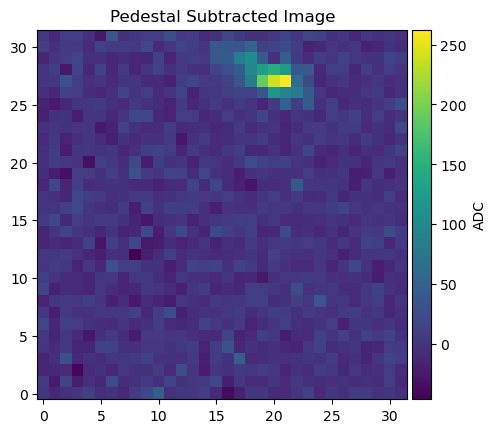

In [12]:
fig = plt.figure()
image = plt.imshow(ped_subtracted_event.reshape(32,32), aspect="equal", origin='lower')
colorbar(image, "ADC")
plt.title("Pedestal Subtracted Image")

Here is the pedestal variance that will be used for threshold cleaning

Text(0.5, 1.0, 'Pedestal Variance')

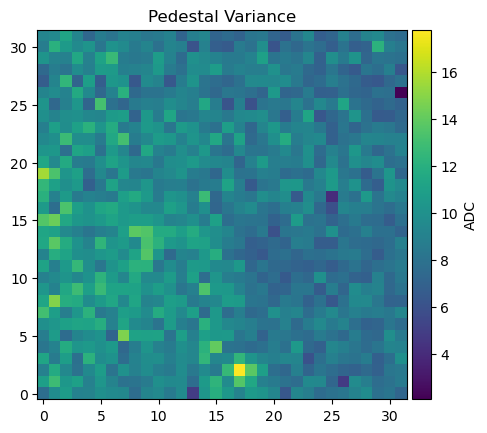

In [13]:
fig = plt.figure()
image = plt.imshow(pedestal_variance.reshape(32,32), aspect="equal", origin='lower')
colorbar(image, "ADC")
plt.title("Pedestal Variance")

In [14]:
from heap.image_cleaning import threshold_clean

Now let's do a simple example of image cleaning

Note that this function is expecting a 2D image, so we will have to reshape the inputs

In [15]:
cleaned_event, mask = threshold_clean(ped_subtracted_event.reshape(32,32), pedestal_variance.reshape(32,32))

`threshold_clean()` returns the cleaned image, and a mask of the removed pixels. The mask is just a binary mapping. Here's what that looks like:

Text(0.5, 1.0, 'Removed Pixels')

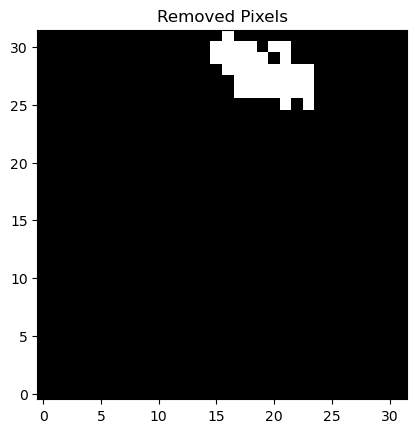

In [16]:
fig = plt.figure()
image=plt.imshow(mask, aspect="equal",cmap='binary_r', origin='lower')
plt.title("Removed Pixels")

And here is the final, cleaned image:

Text(0.5, 1.0, 'Cleaned Image')

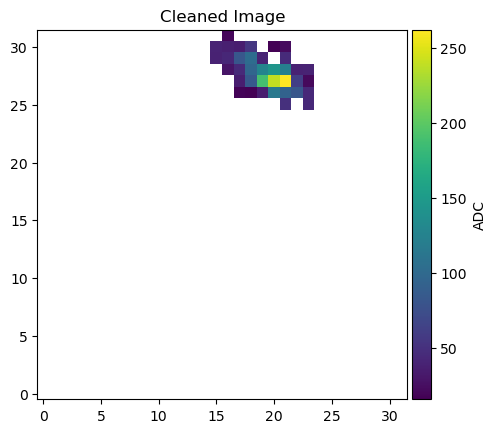

In [17]:
fig = plt.figure()
image=plt.imshow(cleaned_event, aspect="equal", origin='lower')
colorbar(image, "ADC")
plt.title("Cleaned Image")

Here's a comparison between the original image and the cleaned image:

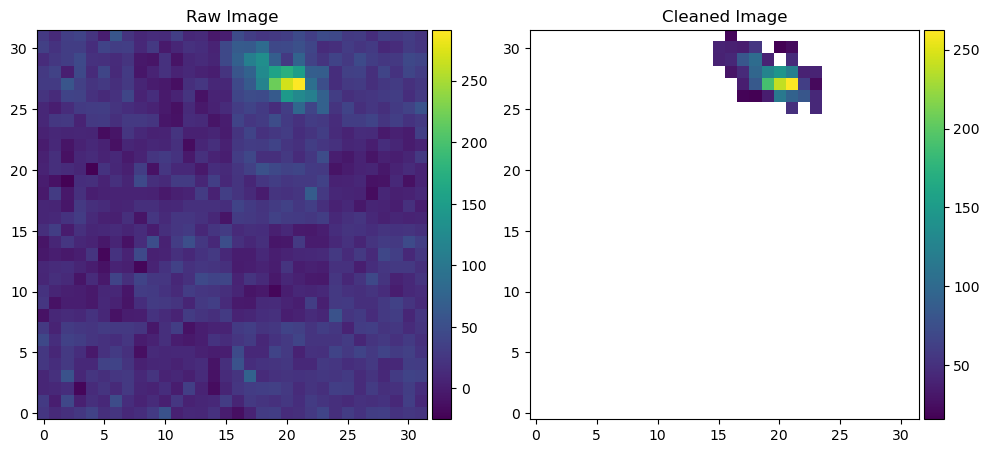

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event.reshape(32,32), aspect="equal", origin='lower')
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event, aspect="equal", origin='lower')
colorbar(image2)
ax2.set_title("Cleaned Image")

fig.tight_layout(h_pad=2)

By default, the image pixel threshold is 4.0 and the border pixel threshold is 2.0. These are in units of the pedestal variance.

We can change this in the function call of `threshold_clean()` like so:

In [19]:
cleaned_event_raised_thresh, mask_raised_thresh = threshold_clean(
                                                    ped_subtracted_event.reshape(32,32), 
                                                    pedestal_variance.reshape(32,32), 
                                                    border_threshold=3.5, 
                                                    image_threshold=7.0
                                                )

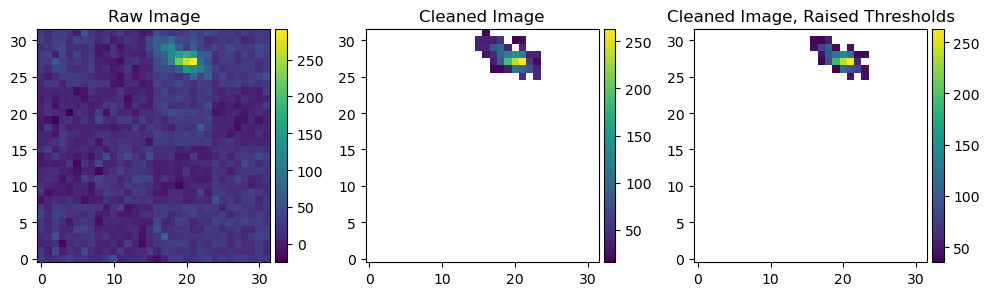

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event.reshape(32,32), aspect="equal", origin='lower')
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event, aspect="equal", origin='lower')
colorbar(image2)
ax2.set_title("Cleaned Image")

# plot the cleaned image with raised cleaning thresholds
image3 = ax3.imshow(cleaned_event_raised_thresh, aspect="equal", origin='lower')
colorbar(image3)
ax3.set_title("Cleaned Image, Raised Thresholds")

fig.tight_layout(h_pad=2)

Here's another example of threshold cleaning (with default thresholds) on a dimmer event.

In [21]:
event2 = data[511]

In [22]:
pedestal2, pedestal_variance2 = calculate_pedestal_and_pedvar(data[0:200])

In [23]:
ped_subtracted_event2 = event2-pedestal2

In [24]:
cleaned_event2, mask2 = threshold_clean(ped_subtracted_event2.reshape(32,32), pedestal_variance2.reshape(32,32))

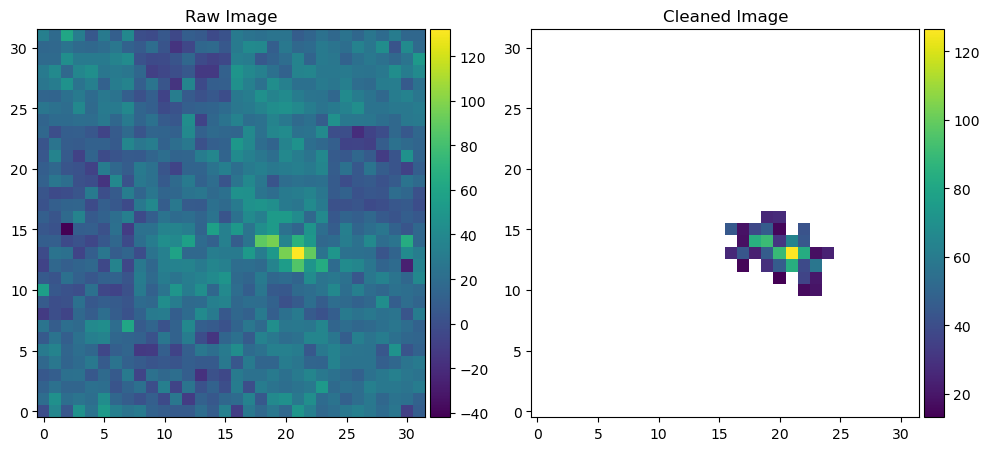

In [25]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event2.reshape(32,32), aspect="equal", origin='lower')
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event2, aspect="equal", origin='lower')
colorbar(image2)
ax2.set_title("Cleaned Image")

fig.tight_layout(h_pad=2)